#  826 – AutoML : LSTM Autoencoder pour la Cristallisation

## Architecture globale

```
Données brutes (séries temporelles hourly)
        │
        ▼
┌─────────────────────────────────────────────────────┐
│  PREPROCESSING                                       │
│  • Fenêtres glissantes (19h × 5 canaux)              │
│  • Normalisation MinMax par canal                    │
│  • 6 390 fenêtres issues des 4 campagnes             │
└─────────────────────────────────────────────────────┘
        │
        ▼
┌─────────────────────────────────────────────────────┐
│  LSTM AUTOENCODER  (non supervisé)                   │
│                                                      │
│  Input (19, 5)                                       │
│     → Encoder LSTM  → vecteur latent (dim=16)        │
│     → Decoder LSTM  → reconstruction (19, 5)         │
│                                                      │
│  Loss = MSE(input, reconstruction)                   │
│  Entraîné sur toutes les fenêtres glissantes         │
└─────────────────────────────────────────────────────┘
        │
        ├────────────────────────┬──────────────────────┐
        ▼                        ▼                       ▼
┌──────────────┐    ┌───────────────────────┐  ┌──────────────────┐
│  ANOMALIE    │    │  CLUSTERING           │  │  RÉGRESSION      │
│  DETECTION   │    │  K-Means sur espace   │  │  durée cycle     │
│              │    │  latent               │  │                  │
│  Score =     │    │  Profils automatiques │  │  Ridge + RF sur  │
│  erreur de   │    │  des cycles           │  │  vecteur latent  │
│  reconstruc. │    │                       │  │  (features appr) │
└──────────────┘    └───────────────────────┘  └──────────────────┘
```

> **cette approche est puissante avec peu de données :**
> - L'autoencoder apprend sur **6 390 fenêtres**  
> - Le vecteur latent est une **représentation dense et apprise** — bien meilleure que des features manuelles  
> - L'erreur de reconstruction est un **score d'anomalie naturel** — zéro label nécessaire  
> - Compatible **IBM Watson.ai** (export `.h5` / `ONNX`)

---

## Dépendances
```bash
pip install tensorflow scikit-learn umap-learn matplotlib pandas numpy
```


## 0. Imports & Configuration

In [17]:
import os, warnings
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

# ML / DL
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, callbacks
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score, LeaveOneOut
from sklearn.metrics import mean_absolute_error, r2_score, silhouette_score
from sklearn.decomposition import PCA

try:
    import umap
    UMAP_OK = True
except ImportError:
    UMAP_OK = False

tf.random.set_seed(42)
np.random.seed(42)

print(f"TensorFlow : {tf.__version__}")
print(f"UMAP       : {'disponible' if UMAP_OK else 'non installé (pip install umap-learn)'}")
print(f"GPU        : {tf.config.list_physical_devices('GPU') or 'aucun (CPU mode)'}")

# ── Chemins ──────────────────────────────────────────────────────────────────
DATA_DIR = Path("data2")

FILES = {
    "Campaign 5": DATA_DIR / "T826_CRYSTALLIZER_202603_CAMPAIGN_5_PIVOTBYHOUR.csv",
    "Campaign 6": DATA_DIR / "T826_CRYSTALLIZER_202603_CAMPAIGN_6_PIVOTBYHOUR.csv",
    "Campaign 7": DATA_DIR / "T826_CRYSTALLIZER_202603_CAMPAIGN_7_PIVOTBYHOUR.csv",
    "Campaign 8": DATA_DIR / "T826_CRYSTALLIZER_202603_CAMPAIGN_8_PIVOTBYHOUR.csv",
}

CRYSTALLIZERS = {
    "C1": ("AVG_826LR04", "AVG_826TRC07", "AVG_826TRC07_DELTAT"),
    "C2": ("AVG_826LR05", "AVG_826TRC08", "AVG_826TRC08_DELTAT"),
    "C3": ("AVG_826LR06", "AVG_826TRC09", "AVG_826TRC09_DELTAT"),
}

# ── Hyperparamètres ───────────────────────────────────────────────────────────
WINDOW_SIZE   = 19    # 6h avant + front + 12h après = 19 pas de temps
LATENT_DIM    = 16    # taille du vecteur latent
LSTM_UNITS    = 32    # unités LSTM encoder/decoder
BATCH_SIZE    = 64
EPOCHS        = 80
LR_THRESHOLD  = 50    # seuil détection front montant (%)
TRC_SURGE     = 5.0   # seuil montée température (°C/h)
WINDOW_PRE    = 6     # heures avant le front
WINDOW_POST   = 12    # heures après le front
N_CLUSTERS    = 3     # nombre de clusters (validé par silhouette)

COLORS = ["#E74C3C", "#2ECC71", "#3498DB", "#F39C12", "#9B59B6"]
print("\n✅ Configuration chargée")


TensorFlow : 2.21.0
UMAP       : disponible
GPU        : aucun (CPU mode)

✅ Configuration chargée


## 1. Préparation des Données

### 1.1 Fenêtres glissantes — la clé de l'approche

Au lieu de résumer chaque cycle en 10 features, on **découpe les séries en fenêtres de 19h**  
avec un pas de 1h (stride=1). Cela donne **6 390 fenêtres** issues des 4 campagnes.

L'autoencoder apprend ainsi la **forme normale** d'une série LR/TRC,  
et pourra détecter les cycles qui dévient de cette norme.

**5 canaux par fenêtre :**

| Canal | Description |
|-------|-------------|
| `LR` | Niveau du cristalliseur (%) |
| `TRC` | Température (°C) |
| `DeltaT` | Dérivée intégrée de la température |
| `diff_TRC` | Variation horaire de TRC (°C/h) |
| `diff_LR` | Variation horaire du niveau (%/h) |


In [18]:
def load_campaign(filepath):
    df = pd.read_csv(filepath)
    df["ts"] = pd.to_datetime(df["INSTRUMENT_TAG_TS"], format="%Y-%m-%d %H")
    return df.sort_values("ts").reset_index(drop=True)

def detect_fronts(df, lr_col, trc_col):
    lr  = df[lr_col].fillna(0)
    trc = df[trc_col].fillna(0)
    lr_cross  = (lr > LR_THRESHOLD) & (lr.shift(1, fill_value=0) <= LR_THRESHOLD)
    trc_surge = trc.diff().rolling(2, min_periods=1).max() > TRC_SURGE
    return df.index[lr_cross & trc_surge].tolist()

def build_window(df, lr_col, trc_col, dt_col, start, end):
    """Construit un tenseur (WINDOW_SIZE, 5) pour une fenêtre donnée."""
    seg = df.iloc[start:end]
    lr  = seg[lr_col].ffill().fillna(0).values
    trc = seg[trc_col].ffill().fillna(0).values
    dt  = seg[dt_col].fillna(0).values
    return np.stack([
        lr, trc, dt,
        np.diff(trc, prepend=trc[0]),
        np.diff(lr,  prepend=lr[0])
    ], axis=1).astype(np.float32)

# ── Chargement de toutes les campagnes ───────────────────────────────────────
campaigns = {name: load_campaign(path) for name, path in FILES.items()}

# ── 1. Fenêtres GLISSANTES → entraînement autoencoder ───────────────────────
all_sliding = []
window_meta  = []   # métadonnées pour traçabilité

for camp_name, df in campaigns.items():
    for cryst_id, (lc, tc, dtc) in CRYSTALLIZERS.items():
        for i in range(0, len(df) - WINDOW_SIZE, 1):
            w = build_window(df, lc, tc, dtc, i, i + WINDOW_SIZE)
            all_sliding.append(w)
            window_meta.append({"camp": camp_name, "cryst": cryst_id,
                                 "start_ts": df["ts"].iloc[i]})

X_all  = np.array(all_sliding)   # (6390, 19, 5)
meta_df = pd.DataFrame(window_meta)

# ── 2. Fenêtres DE CYCLE → détection anomalies + régression ─────────────────
cycle_windows = []
cycle_meta    = []

for camp_name, df in campaigns.items():
    for cryst_id, (lc, tc, dtc) in CRYSTALLIZERS.items():
        fronts = detect_fronts(df, lc, tc)
        for i, idx in enumerate(fronts):
            start = idx - WINDOW_PRE
            end   = idx + WINDOW_POST + 1
            if start < 0 or end > len(df):
                continue
            w = build_window(df, lc, tc, dtc, start, end)
            if w.shape[0] != WINDOW_SIZE:
                continue
            # Durée cible : heures jusqu'à TRC < 40°C après le front
            post_trc = df[tc].fillna(0).values[idx:end]
            below40  = np.where(post_trc < 40)[0]
            duration = int(below40[0]) if len(below40) > 0 else WINDOW_POST
            cycle_windows.append(w)
            cycle_meta.append({
                "camp": camp_name, "cryst": cryst_id,
                "front_time": df["ts"].iloc[idx],
                "duration_h": duration,
                "front_idx": idx,
            })

X_cycles   = np.array(cycle_windows)
df_cycles  = pd.DataFrame(cycle_meta)

print(f"✅ Fenêtres glissantes  : {X_all.shape}  (autoencoder training)")
print(f"✅ Fenêtres de cycles   : {X_cycles.shape} (anomalie + régression)")
print(f"   Durée cible → min={df_cycles['duration_h'].min()}h  "
      f"max={df_cycles['duration_h'].max()}h  "
      f"moy={df_cycles['duration_h'].mean():.1f}h")


✅ Fenêtres glissantes  : (6390, 19, 5)  (autoencoder training)
✅ Fenêtres de cycles   : (36, 19, 5) (anomalie + régression)
   Durée cible → min=1h  max=12h  moy=6.6h


### 1.2 Normalisation

On normalise **chaque canal indépendamment** (MinMaxScaler) sur l'ensemble des données glissantes.  
Le scaler est ensuite appliqué à l'identique sur les fenêtres de cycles.

> **Important :** Le scaler est **fitté uniquement sur X_all** (données d'entraînement),  
> jamais sur les données de test — pour éviter le data leakage.


✅ Normalisation MinMax [-1, 1] par canal
   X_all_norm   : (6390, 19, 5)  min=-1.00  max=1.00
   X_cycles_norm: (36, 19, 5)


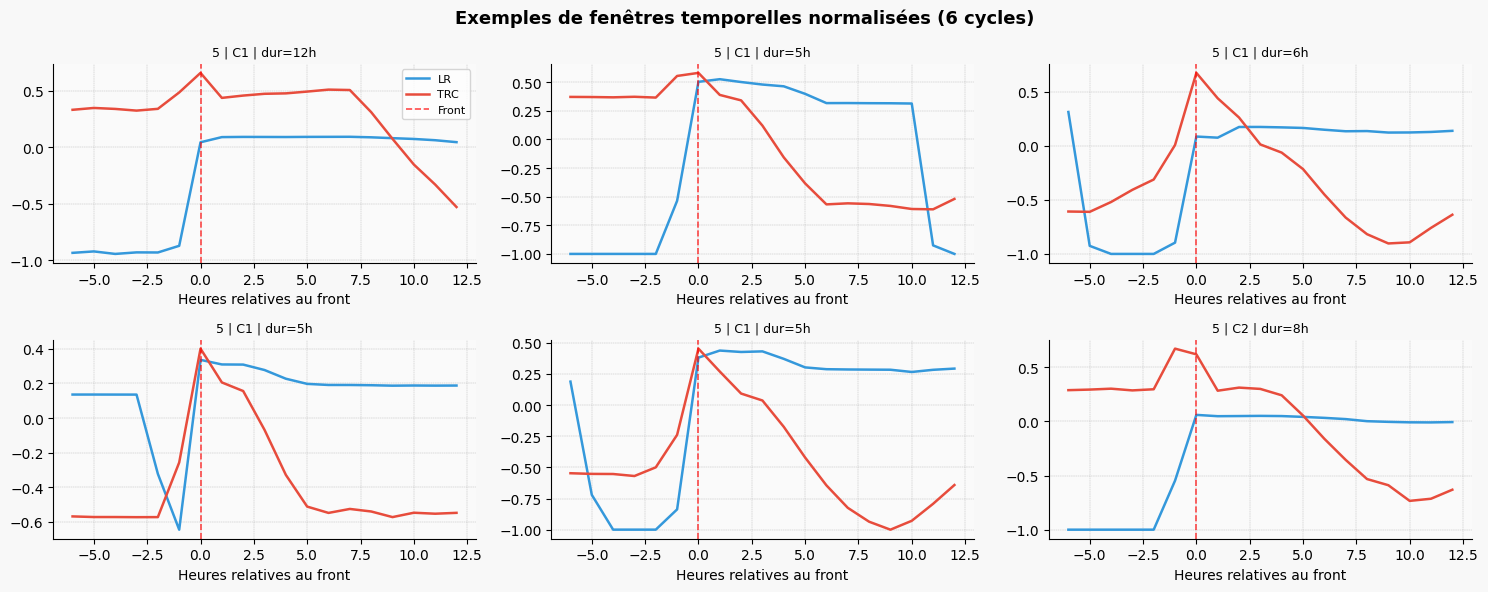

In [19]:
N_CHANNELS = X_all.shape[2]   # 5

# Fit un scaler par canal
scalers = []
X_all_norm = X_all.copy()

for c in range(N_CHANNELS):
    sc = MinMaxScaler(feature_range=(-1, 1))
    flat = X_all[:, :, c].reshape(-1, 1)
    sc.fit(flat)
    X_all_norm[:, :, c] = sc.transform(flat).reshape(X_all.shape[0], WINDOW_SIZE)
    scalers.append(sc)

# Appliquer les mêmes scalers sur les fenêtres de cycles
X_cycles_norm = X_cycles.copy()
for c in range(N_CHANNELS):
    flat = X_cycles[:, :, c].reshape(-1, 1)
    X_cycles_norm[:, :, c] = scalers[c].transform(flat).reshape(X_cycles.shape[0], WINDOW_SIZE)

print("✅ Normalisation MinMax [-1, 1] par canal")
print(f"   X_all_norm   : {X_all_norm.shape}  min={X_all_norm.min():.2f}  max={X_all_norm.max():.2f}")
print(f"   X_cycles_norm: {X_cycles_norm.shape}")

# Visualisation de quelques fenêtres normalisées
fig, axes = plt.subplots(2, 3, figsize=(15, 6))
fig.patch.set_facecolor("#F8F8F8")
fig.suptitle("Exemples de fenêtres temporelles normalisées (6 cycles)", fontsize=13, fontweight="bold")
channels = ["LR", "TRC", "DeltaT", "diff_TRC", "diff_LR"]
colors_ch = ["#3498DB", "#E74C3C", "#2ECC71", "#F39C12", "#9B59B6"]

for ax_idx, ax in enumerate(axes.flatten()):
    if ax_idx >= len(X_cycles_norm): break
    ax.set_facecolor("#FAFAFA")
    ax.spines[["top","right"]].set_visible(False)
    t = np.arange(WINDOW_SIZE) - WINDOW_PRE
    for c, (ch, col) in enumerate(zip(channels[:2], colors_ch[:2])):
        ax.plot(t, X_cycles_norm[ax_idx, :, c], color=col, linewidth=1.8, label=ch)
    ax.axvline(0, color="red", linestyle="--", linewidth=1.2, alpha=0.7, label="Front")
    ax.set_title(f"{df_cycles.iloc[ax_idx]['camp'][-1:]} | "
                 f"{df_cycles.iloc[ax_idx]['cryst']} | "
                 f"dur={df_cycles.iloc[ax_idx]['duration_h']}h", fontsize=9)
    ax.set_xlabel("Heures relatives au front"); ax.grid(linestyle="--", linewidth=0.3)
    if ax_idx == 0: ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


## 2. LSTM Autoencoder

### Architecture

```
Input  (batch, 19, 5)
  │
  ▼  Encoder
  LSTM(32, return_sequences=True)  → (batch, 19, 32)
  LSTM(16, return_sequences=False) → (batch, 16)        ← bottleneck
  Dense(LATENT_DIM=16, relu)       → vecteur latent z
  │
  ▼  Decoder
  RepeatVector(19)                 → (batch, 19, 16)
  LSTM(16, return_sequences=True)  → (batch, 19, 16)
  LSTM(32, return_sequences=True)  → (batch, 19, 32)
  TimeDistributed Dense(5)         → (batch, 19, 5)     ← reconstruction
```

**Dropout (0.2)** sur chaque LSTM pour régularisation (éviter l'overfitting sur CPU).  
**Loss = MSE** entre l'entrée et la reconstruction.

> Le vecteur latent `z` (dim=16) est la **représentation comprimée** du cycle :  
> il capture la forme, l'intensité thermique, la dynamique de remplissage.


In [20]:
def build_autoencoder(window_size, n_channels, latent_dim, lstm_units):
    """Construit le LSTM Autoencoder avec extraction du vecteur latent."""
    inp = keras.Input(shape=(window_size, n_channels), name="input")

    # ── Encoder ──────────────────────────────────────────────────────────────
    x = layers.LSTM(lstm_units, return_sequences=True,
                    dropout=0.2, name="enc_lstm1")(inp)
    x = layers.LSTM(latent_dim, return_sequences=False,
                    dropout=0.2, name="enc_lstm2")(x)
    z = layers.Dense(latent_dim, activation="relu", name="latent")(x)

    # ── Decoder ──────────────────────────────────────────────────────────────
    x = layers.RepeatVector(window_size, name="repeat")(z)
    x = layers.LSTM(latent_dim, return_sequences=True,
                    dropout=0.2, name="dec_lstm1")(x)
    x = layers.LSTM(lstm_units, return_sequences=True,
                    dropout=0.2, name="dec_lstm2")(x)
    out = layers.TimeDistributed(
        layers.Dense(n_channels), name="reconstruction")(x)

    autoencoder = Model(inp, out, name="LSTM_Autoencoder")
    encoder     = Model(inp, z,   name="Encoder")
    return autoencoder, encoder

autoencoder, encoder = build_autoencoder(
    WINDOW_SIZE, N_CHANNELS, LATENT_DIM, LSTM_UNITS)

autoencoder.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse"
)

autoencoder.summary()
print(f"\n   Paramètres totaux : {autoencoder.count_params():,}")
print(f"   Vecteur latent    : dim={LATENT_DIM}")


Model: "LSTM_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 19, 5)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_lstm1 (LSTM)                │ (None, 19, 32)         │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_lstm2 (LSTM)                │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat (RepeatVector)           │ (None, 19, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_lstm1 (LSTM)                │ (None, 19, 16)         │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_lstm2 (LSTM)                │ (None, 19, 32)         │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstruction                  │ (None, 19, 5)          │           165 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,821 (65.71 KB)

 Trainable params: 16,821 (65.71 KB)

 Non-trainable params: 0 (0.00 B)


   Paramètres totaux : 16,821
   Vecteur latent    : dim=16


### 2.1 Entraînement

L'autoencoder est entraîné sur **toutes les fenêtres glissantes** (6 390).  
Il apprend à **reconstruire** les séries LR/TRC normales.  

Callbacks :
- **EarlyStopping** : arrêt si la validation loss ne s'améliore plus (patience=10)
- **ReduceLROnPlateau** : réduit le learning rate si plateau (factor=0.5)
- **ModelCheckpoint** : sauvegarde le meilleur modèle

> Temps estimé sur CPU : ~3–8 minutes selon la machine.


In [ ]:
# Split train/val (80/20 aléatoire)
idx_all = np.random.permutation(len(X_all_norm))
split   = int(0.8 * len(idx_all))
X_train = X_all_norm[idx_all[:split]]
X_val   = X_all_norm[idx_all[split:]]

print(f"Train : {X_train.shape[0]} fenêtres")
print(f"Val   : {X_val.shape[0]} fenêtres")

cb_list = [
    callbacks.EarlyStopping(monitor="val_loss", patience=10,
                             restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                 patience=5, min_lr=1e-5, verbose=1),
    callbacks.ModelCheckpoint("best_autoencoder.keras",
                               monitor="val_loss", save_best_only=True, verbose=0),
]

history = autoencoder.fit(
    X_train, X_train,
    validation_data=(X_val, X_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=cb_list,
    verbose=1,
)

print(f"\n✅ Entraînement terminé — {len(history.history['loss'])} epochs")
print(f"   Best val_loss : {min(history.history['val_loss']):.6f}")


Train : 5112 fenêtres
Val   : 1278 fenêtres
Epoch 1/80
80/80 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.1332 - val_loss: 0.0609 - learning_rate: 0.0010
Epoch 2/80
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0749 - val_loss: 0.0501 - learning_rate: 0.0010
Epoch 3/80
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0655 - val_loss: 0.0445 - learning_rate: 0.0010
Epoch 4/80
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0622 - val_loss: 0.0403 - learning_rate: 0.0010
Epoch 5/80
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0606 - val_loss: 0.0357 - learning_rate: 0.0010
Epoch 6/80
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0589 - val_loss: 0.0349 - learning_rate: 0.0010
Epoch 7/80
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0563 - val_loss: 0.0336 - learning_rate: 0.0010
Epoch 8/80
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0540 - val_loss: 0.0340 - learning_rate: 0.0010
Epoch 9/80
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0529 - val_loss: 0.0323

### 2.2 Courbes d'Entraînement

Une **val_loss proche de la train_loss** = bon signe (pas d'overfitting).  
Un gap important = le modèle mémorise au lieu d'apprendre.


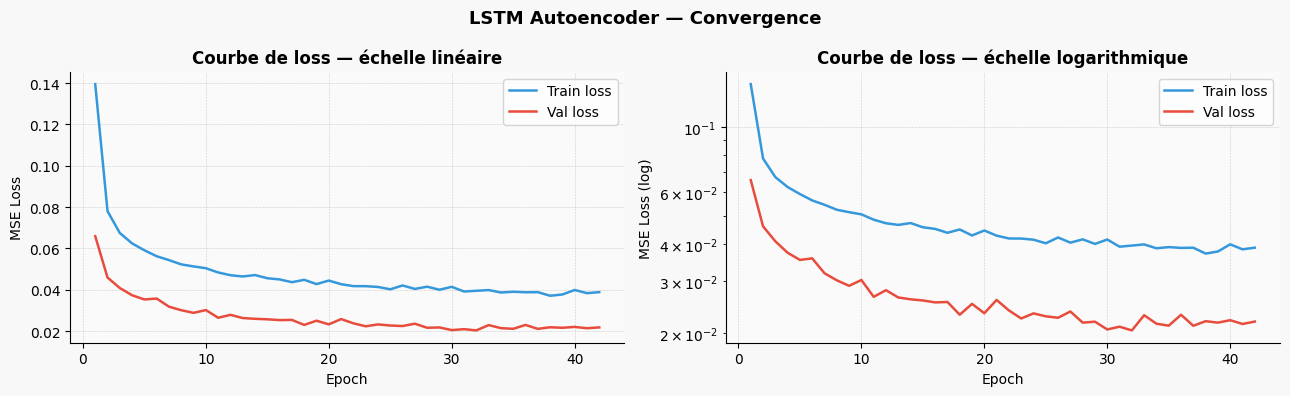

Gap train/val : 0.016754  →  ⚠️ Possible overfitting


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
fig.patch.set_facecolor("#F8F8F8")

train_loss = history.history["loss"]
val_loss   = history.history["val_loss"]
epochs_ran = range(1, len(train_loss) + 1)

for ax in [ax1, ax2]:
    ax.set_facecolor("#FAFAFA")
    ax.spines[["top","right"]].set_visible(False)
    ax.grid(linestyle="--", linewidth=0.4, color="#CCCCCC")

ax1.plot(epochs_ran, train_loss, color="#3498DB", linewidth=1.8, label="Train loss")
ax1.plot(epochs_ran, val_loss,   color="#E74C3C", linewidth=1.8, label="Val loss")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("MSE Loss")
ax1.set_title("Courbe de loss — échelle linéaire", fontweight="bold")
ax1.legend()

ax2.semilogy(epochs_ran, train_loss, color="#3498DB", linewidth=1.8, label="Train loss")
ax2.semilogy(epochs_ran, val_loss,   color="#E74C3C", linewidth=1.8, label="Val loss")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("MSE Loss (log)")
ax2.set_title("Courbe de loss — échelle logarithmique", fontweight="bold")
ax2.legend()

plt.suptitle("LSTM Autoencoder — Convergence", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

gap = abs(min(train_loss) - min(val_loss))
print(f"Gap train/val : {gap:.6f}  →  {'✅ OK (pas d\'overfitting)' if gap < 0.01 else '⚠️ Possible overfitting'}")


### 2.3 Qualité de Reconstruction

On vérifie visuellement que l'autoencoder reconstruit bien les cycles.  
Une bonne reconstruction = le modèle a appris la dynamique LR/TRC.


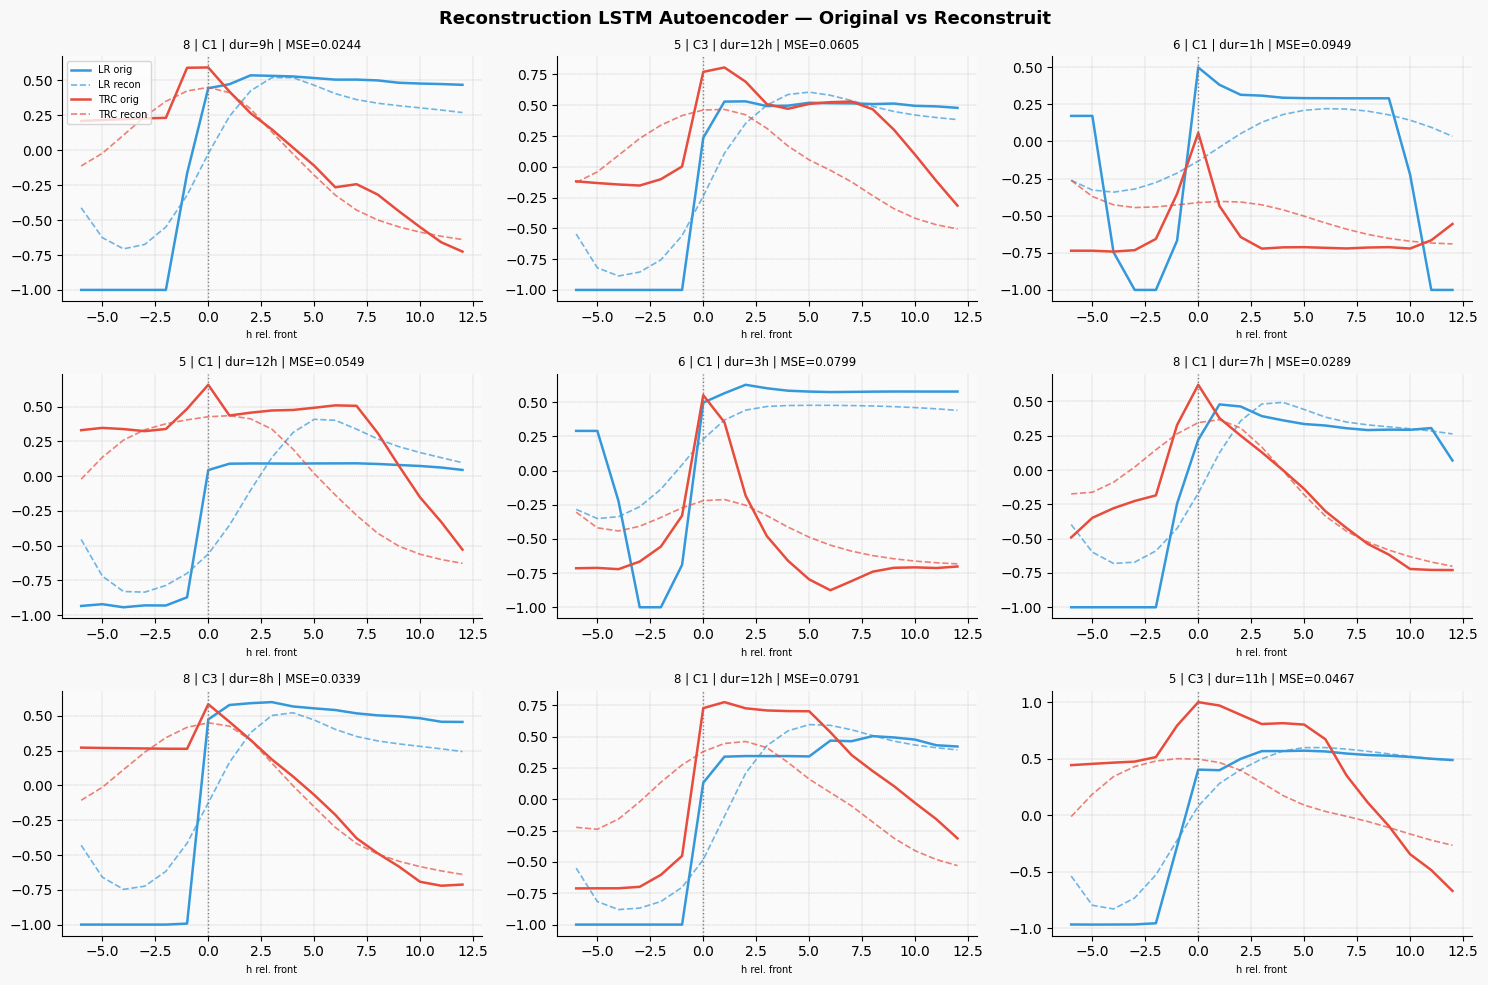

In [ ]:
X_recon = autoencoder.predict(X_cycles_norm, verbose=0)

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
fig.patch.set_facecolor("#F8F8F8")
fig.suptitle("Reconstruction LSTM Autoencoder — Original vs Reconstruit",
             fontsize=13, fontweight="bold")

t = np.arange(WINDOW_SIZE) - WINDOW_PRE
ch_names = ["LR", "TRC", "DeltaT", "diff_TRC", "diff_LR"]

sample_idxs = np.random.choice(len(X_cycles_norm), min(9, len(X_cycles_norm)), replace=False)

for plot_i, ax in enumerate(axes.flatten()):
    if plot_i >= len(sample_idxs): ax.axis("off"); continue
    idx = sample_idxs[plot_i]
    ax.set_facecolor("#FAFAFA")
    ax.spines[["top","right"]].set_visible(False)

    # LR (canal 0)
    ax.plot(t, X_cycles_norm[idx, :, 0], "#3498DB", linewidth=1.8, label="LR orig")
    ax.plot(t, X_recon[idx, :, 0],       "#3498DB", linewidth=1.2,
            linestyle="--", alpha=0.7, label="LR recon")
    # TRC (canal 1)
    ax.plot(t, X_cycles_norm[idx, :, 1], "#E74C3C", linewidth=1.8, label="TRC orig")
    ax.plot(t, X_recon[idx, :, 1],       "#E74C3C", linewidth=1.2,
            linestyle="--", alpha=0.7, label="TRC recon")

    err = np.mean((X_cycles_norm[idx] - X_recon[idx])**2)
    ax.axvline(0, color="gray", linestyle=":", linewidth=1)
    ax.set_title(f"{df_cycles.iloc[idx]['camp'][-1:]} | {df_cycles.iloc[idx]['cryst']} | "
                 f"dur={df_cycles.iloc[idx]['duration_h']}h | MSE={err:.4f}", fontsize=8.5)
    ax.set_xlabel("h rel. front", fontsize=7)
    ax.grid(linestyle="--", linewidth=0.3)
    if plot_i == 0: ax.legend(fontsize=7, loc="upper left")

plt.tight_layout()
plt.show()


---

## 3. Détection d'Anomalies

### Principe

L'erreur de reconstruction (MSE entre original et reconstruit) est le **score d'anomalie** :

- **MSE faible** → le cycle ressemble aux cycles normaux → ✅ nominal
- **MSE élevé**  → le cycle dévie de la norme apprise → ⚠️ anomalie potentielle

Le seuil est déterminé automatiquement par le **percentile 90** des scores sur les cycles connus.

> Cette méthode ne nécessite **aucun label** — c'est l'autoencoder qui définit ce qu'est "normal".


Seuil anomalie (P90) : 0.08639
Cycles anomaliques   : 4 / 36



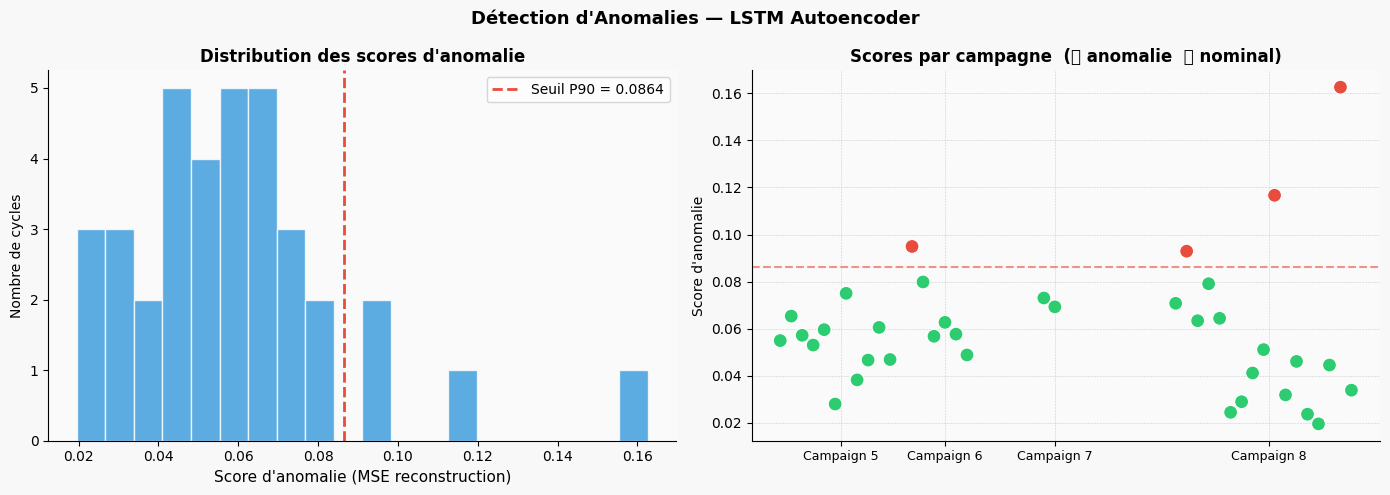

In [ ]:
# ── Calcul des scores d'anomalie ─────────────────────────────────────────────
recon_errors = np.mean((X_cycles_norm - X_recon)**2, axis=(1, 2))
df_cycles["anomaly_score"] = recon_errors

threshold = np.percentile(recon_errors, 90)
df_cycles["is_anomaly"] = (recon_errors > threshold).astype(int)

n_anomalies = df_cycles["is_anomaly"].sum()
print(f"Seuil anomalie (P90) : {threshold:.5f}")
print(f"Cycles anomaliques   : {n_anomalies} / {len(df_cycles)}")
print()

# ── Graphe des scores ─────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor("#F8F8F8")

# Distribution des scores
ax1.set_facecolor("#FAFAFA")
ax1.spines[["top","right"]].set_visible(False)
ax1.hist(recon_errors, bins=20, color="#3498DB", alpha=0.8, edgecolor="white")
ax1.axvline(threshold, color="#E74C3C", linewidth=2, linestyle="--",
            label=f"Seuil P90 = {threshold:.4f}")
ax1.set_xlabel("Score d'anomalie (MSE reconstruction)", fontsize=11)
ax1.set_ylabel("Nombre de cycles", fontsize=10)
ax1.set_title("Distribution des scores d'anomalie", fontsize=12, fontweight="bold")
ax1.legend(fontsize=10)

# Timeline des scores par campagne
ax2.set_facecolor("#FAFAFA")
ax2.spines[["top","right"]].set_visible(False)
ax2.grid(linestyle="--", linewidth=0.4, color="#CCCCCC")

camp_order = df_cycles["camp"].unique()
y_ticks = []
for ci, camp in enumerate(camp_order):
    mask   = df_cycles["camp"] == camp
    scores = df_cycles.loc[mask, "anomaly_score"].values
    is_ano = df_cycles.loc[mask, "is_anomaly"].values
    x_pos  = np.arange(mask.sum())

    ax2.scatter(x_pos + ci * 12, scores,
                c=["#E74C3C" if a else "#2ECC71" for a in is_ano],
                s=100, zorder=3, edgecolors="white", linewidths=0.8)
    y_ticks.append((ci * 12 + mask.sum() / 2, camp))

ax2.axhline(threshold, color="#E74C3C", linewidth=1.5, linestyle="--", alpha=0.6)
ax2.set_ylabel("Score d'anomalie", fontsize=10)
ax2.set_title("Scores par campagne  (🔴 anomalie  🟢 nominal)", fontsize=12, fontweight="bold")
ax2.set_xticks([y[0] for y in y_ticks])
ax2.set_xticklabels([y[1] for y in y_ticks], fontsize=9)

plt.suptitle("Détection d'Anomalies — LSTM Autoencoder", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


⚠️  Cycles identifiés comme anomaliques :



,camp,cryst,front_time,duration_h,anomaly_score
0,Campaign 8,C3,2026-02-08 17:00:00,12,0.162639
1,Campaign 8,C2,2026-02-11 07:00:00,12,0.116684
2,Campaign 6,C1,2025-11-11 08:00:00,1,0.094944
3,Campaign 8,C1,2026-02-10 14:00:00,7,0.092928


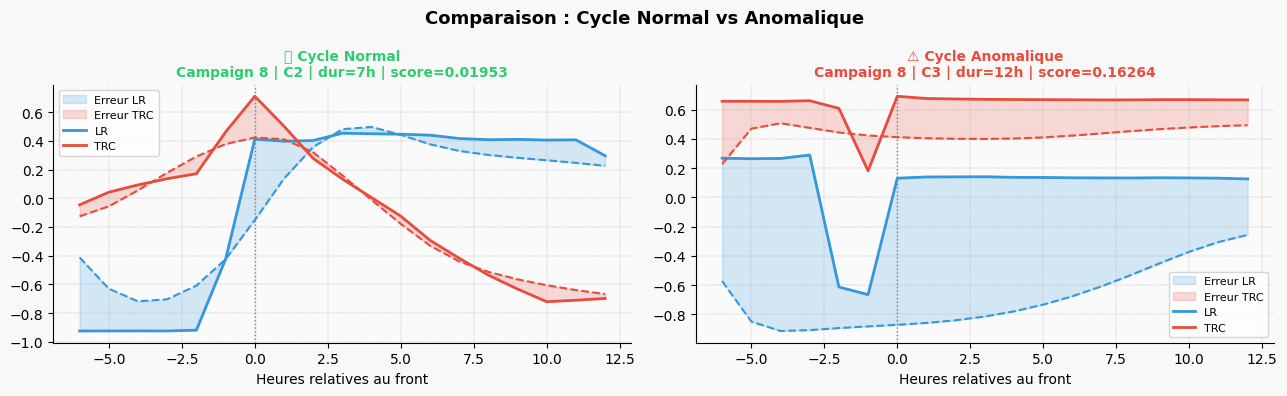

In [ ]:
# ── Détail des cycles anomaliques ────────────────────────────────────────────
print("⚠️  Cycles identifiés comme anomaliques :")
print()
anomalies = df_cycles[df_cycles["is_anomaly"] == 1].sort_values("anomaly_score", ascending=False)
display(anomalies[["camp","cryst","front_time","duration_h",
                    "anomaly_score"]].reset_index(drop=True))

# Visualisation : cycle normal vs anomalique
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.patch.set_facecolor("#F8F8F8")
fig.suptitle("Comparaison : Cycle Normal vs Anomalique", fontsize=13, fontweight="bold")

normal_idx  = df_cycles[df_cycles["is_anomaly"] == 0]["anomaly_score"].idxmin()
anomaly_idx = df_cycles[df_cycles["is_anomaly"] == 1]["anomaly_score"].idxmax()

t = np.arange(WINDOW_SIZE) - WINDOW_PRE

for ax, idx, label, color in [
    (axes[0], normal_idx,  "✅ Cycle Normal",    "#2ECC71"),
    (axes[1], anomaly_idx, "⚠️ Cycle Anomalique", "#E74C3C"),
]:
    ax.set_facecolor("#FAFAFA")
    ax.spines[["top","right"]].set_visible(False)
    ax.grid(linestyle="--", linewidth=0.3)
    ax.fill_between(t,
                    X_cycles_norm[idx, :, 0],
                    X_recon[idx, :, 0],
                    alpha=0.2, color="#3498DB", label="Erreur LR")
    ax.fill_between(t,
                    X_cycles_norm[idx, :, 1],
                    X_recon[idx, :, 1],
                    alpha=0.2, color="#E74C3C", label="Erreur TRC")
    ax.plot(t, X_cycles_norm[idx, :, 0], "#3498DB", linewidth=2, label="LR")
    ax.plot(t, X_recon[idx, :, 0],       "#3498DB", linewidth=1.5, linestyle="--")
    ax.plot(t, X_cycles_norm[idx, :, 1], "#E74C3C", linewidth=2, label="TRC")
    ax.plot(t, X_recon[idx, :, 1],       "#E74C3C", linewidth=1.5, linestyle="--")
    ax.axvline(0, color="gray", linestyle=":", linewidth=1)
    score = df_cycles.iloc[idx]["anomaly_score"]
    meta  = df_cycles.iloc[idx]
    ax.set_title(f"{label}\n{meta['camp']} | {meta['cryst']} | "
                 f"dur={meta['duration_h']}h | score={score:.5f}",
                 fontsize=10, fontweight="bold", color=color)
    ax.set_xlabel("Heures relatives au front")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


---

## 4. Clustering dans l'Espace Latent

### Pourquoi l'espace latent ?

Le vecteur latent `z` (dim=16) est une **représentation apprise** par le réseau.  
Il capture les structures profondes des cycles — bien mieux que nos 10 features manuelles.

En clustering sur `z`, on groupe les cycles par **similarité de forme et de dynamique**,  
pas juste par valeurs de surface.


Vecteurs latents : (36, 16)  (36 cycles × 16 dims)


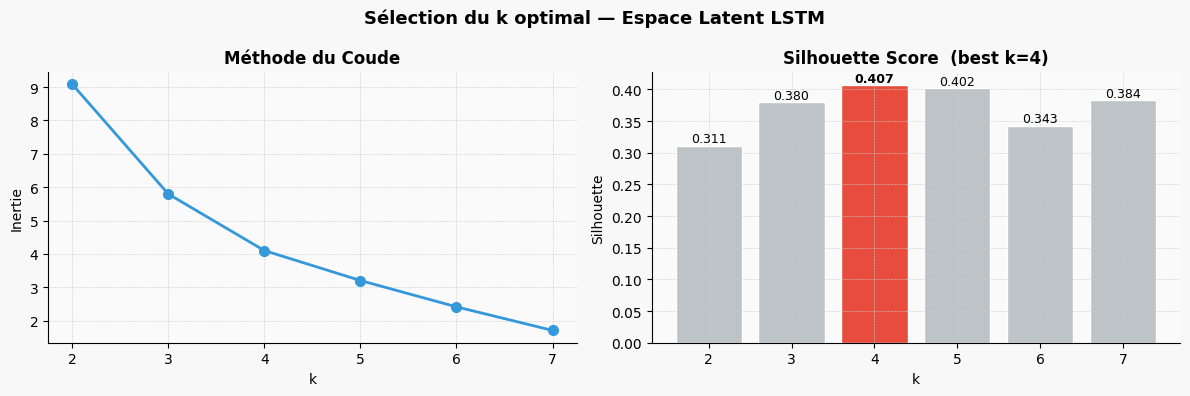


✅ k optimal : 4  (silhouette=0.407)


In [ ]:
# ── Extraction des vecteurs latents ──────────────────────────────────────────
Z_cycles = encoder.predict(X_cycles_norm, verbose=0)
print(f"Vecteurs latents : {Z_cycles.shape}  ({len(df_cycles)} cycles × {LATENT_DIM} dims)")

# ── Choix k optimal ───────────────────────────────────────────────────────────
from sklearn.metrics import silhouette_score

inertias, silhouettes = [], []
K_range = range(2, min(8, len(df_cycles) - 1))

for k in K_range:
    km  = KMeans(n_clusters=k, random_state=42, n_init=20)
    lbl = km.fit_predict(Z_cycles)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(Z_cycles, lbl))

best_k = list(K_range)[np.argmax(silhouettes)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.patch.set_facecolor("#F8F8F8")
for ax in [ax1, ax2]:
    ax.set_facecolor("#FAFAFA")
    ax.spines[["top","right"]].set_visible(False)
    ax.grid(linestyle="--", linewidth=0.4, color="#CCCCCC")

ax1.plot(list(K_range), inertias, "o-", color="#3498DB", linewidth=2, markersize=7)
ax1.set_title("Méthode du Coude", fontweight="bold")
ax1.set_xlabel("k"); ax1.set_ylabel("Inertie")

bar_colors = ["#E74C3C" if k == best_k else "#BDC3C7" for k in K_range]
ax2.bar(list(K_range), silhouettes, color=bar_colors, edgecolor="white")
for k, v in zip(K_range, silhouettes):
    ax2.text(k, v + 0.005, f"{v:.3f}", ha="center", fontsize=9,
             fontweight="bold" if k == best_k else "normal")
ax2.set_title(f"Silhouette Score  (best k={best_k})", fontweight="bold")
ax2.set_xlabel("k"); ax2.set_ylabel("Silhouette")

plt.suptitle("Sélection du k optimal — Espace Latent LSTM", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"\n✅ k optimal : {best_k}  (silhouette={max(silhouettes):.3f})")
N_CLUSTERS = best_k


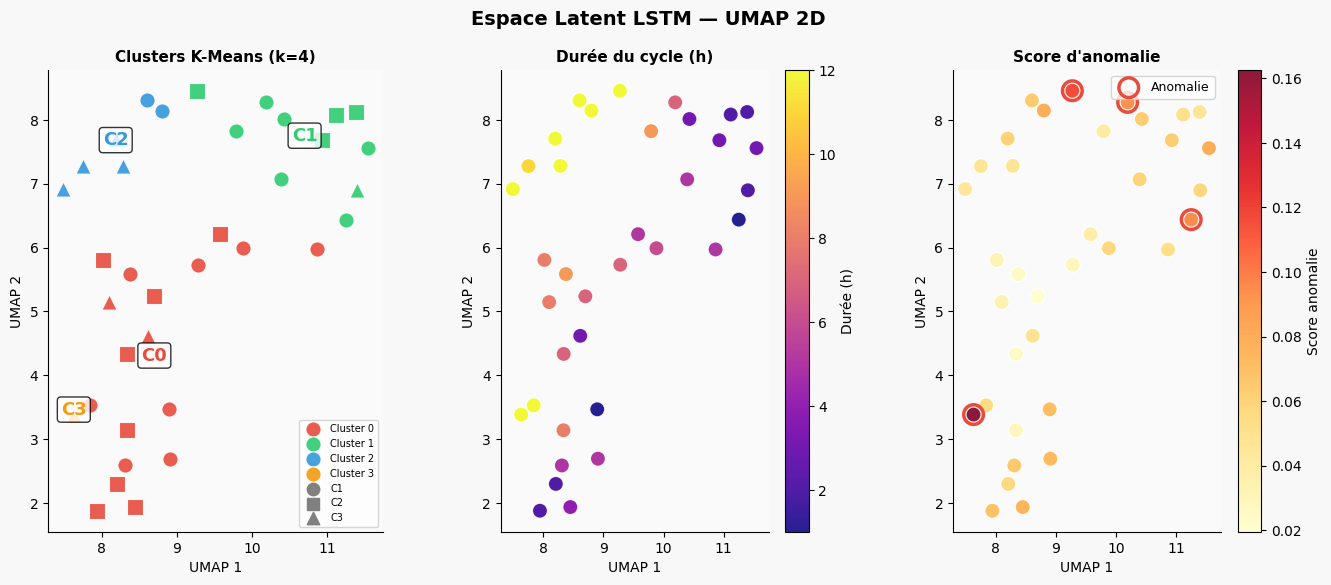

In [ ]:
# ── K-Means final ─────────────────────────────────────────────────────────────
km_final = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=30)
df_cycles["cluster"] = km_final.fit_predict(Z_cycles)

# ── Réduction 2D (UMAP > PCA) ─────────────────────────────────────────────────
if UMAP_OK:
    reducer  = umap.UMAP(n_neighbors=min(8, len(Z_cycles)-1),
                         min_dist=0.25, random_state=42)
    method   = "UMAP"
else:
    reducer  = PCA(n_components=2)
    method   = "PCA"

Z_2d = reducer.fit_transform(Z_cycles)
df_cycles["z1"] = Z_2d[:, 0]
df_cycles["z2"] = Z_2d[:, 1]

# ── Visualisation ─────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 6))
fig.patch.set_facecolor("#F8F8F8")
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

cryst_markers = {"C1": "o", "C2": "s", "C3": "^"}

# — Gauche : par cluster
ax1 = fig.add_subplot(gs[0])
ax1.set_facecolor("#FAFAFA"); ax1.spines[["top","right"]].set_visible(False)
for cl in range(N_CLUSTERS):
    mask = df_cycles["cluster"] == cl
    for cryst, mk in cryst_markers.items():
        sub = df_cycles[mask & (df_cycles["cryst"] == cryst)]
        ax1.scatter(sub["z1"], sub["z2"], color=COLORS[cl], marker=mk,
                    s=120, alpha=0.9, edgecolors="white", linewidths=0.8,
                    label=f"Cluster {cl}" if cryst == "C1" else "")
    cx, cy = df_cycles.loc[mask,"z1"].mean(), df_cycles.loc[mask,"z2"].mean()
    ax1.text(cx, cy, f"C{cl}", fontsize=13, fontweight="bold",
             color=COLORS[cl], ha="center",
             bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.8))

for cryst, mk in cryst_markers.items():
    ax1.scatter([], [], marker=mk, color="gray", s=80, label=cryst)
ax1.set_title(f"Clusters K-Means (k={N_CLUSTERS})", fontsize=11, fontweight="bold")
ax1.set_xlabel(f"{method} 1"); ax1.set_ylabel(f"{method} 2")
ax1.legend(fontsize=7)

# — Centre : par durée
ax2 = fig.add_subplot(gs[1])
ax2.set_facecolor("#FAFAFA"); ax2.spines[["top","right"]].set_visible(False)
sc = ax2.scatter(df_cycles["z1"], df_cycles["z2"],
                 c=df_cycles["duration_h"], cmap="plasma",
                 s=120, alpha=0.9, edgecolors="white")
plt.colorbar(sc, ax=ax2, label="Durée (h)")
ax2.set_title("Durée du cycle (h)", fontsize=11, fontweight="bold")
ax2.set_xlabel(f"{method} 1"); ax2.set_ylabel(f"{method} 2")

# — Droite : par anomalie score
ax3 = fig.add_subplot(gs[2])
ax3.set_facecolor("#FAFAFA"); ax3.spines[["top","right"]].set_visible(False)
sc3 = ax3.scatter(df_cycles["z1"], df_cycles["z2"],
                  c=df_cycles["anomaly_score"], cmap="YlOrRd",
                  s=120, alpha=0.9, edgecolors="white")
plt.colorbar(sc3, ax=ax3, label="Score anomalie")
# Marquer les anomalies
ano = df_cycles[df_cycles["is_anomaly"] == 1]
ax3.scatter(ano["z1"], ano["z2"], facecolors="none", edgecolors="#E74C3C",
            s=200, linewidths=2.5, label="Anomalie")
ax3.set_title("Score d'anomalie", fontsize=11, fontweight="bold")
ax3.set_xlabel(f"{method} 1"); ax3.set_ylabel(f"{method} 2")
ax3.legend(fontsize=9)

plt.suptitle(f"Espace Latent LSTM — {method} 2D", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


### 4.1 Profil des Clusters

On visualise les **séries temporelles moyennes** de chaque cluster —  
une interprétation beaucoup plus riche qu'un simple tableau de statistiques.


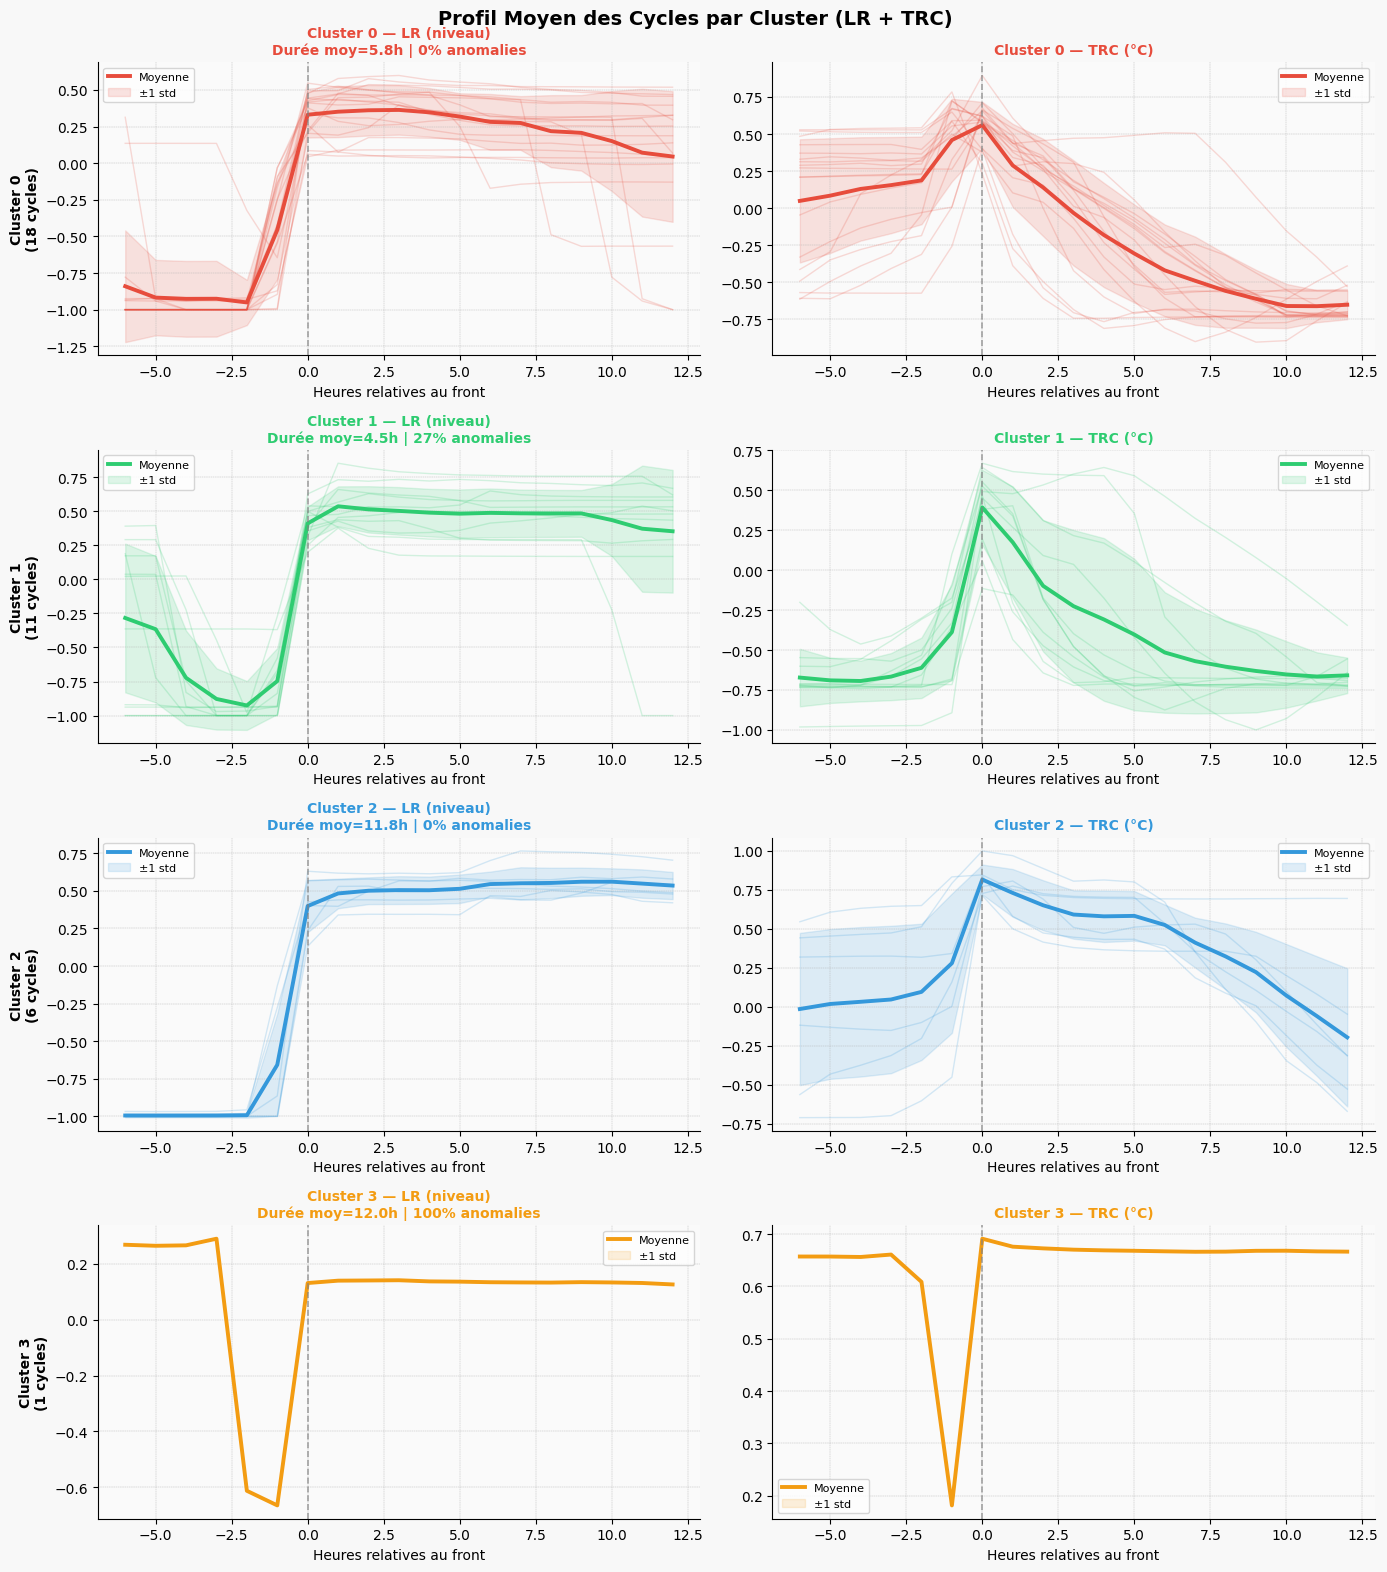


📊 Profil des clusters :


,n_cycles,dur_moy,dur_std,anomalies,score_moy
cluster,,,,,
0,18,5.78,2.80,0,0.05
1,11,4.45,3.47,3,0.07
2,6,11.83,0.41,0,0.06
3,1,12.00,NaN,1,0.16


In [ ]:
t = np.arange(WINDOW_SIZE) - WINDOW_PRE
ch_labels = ["LR (niveau %)", "TRC (°C)", "DeltaT", "diff_TRC", "diff_LR"]

fig, axes = plt.subplots(N_CLUSTERS, 2, figsize=(14, 4*N_CLUSTERS))
fig.patch.set_facecolor("#F8F8F8")
fig.suptitle("Profil Moyen des Cycles par Cluster (LR + TRC)", fontsize=14, fontweight="bold")

for cl in range(N_CLUSTERS):
    mask    = df_cycles["cluster"] == cl
    idxs    = df_cycles.index[mask].tolist()
    n_cyc   = len(idxs)
    color   = COLORS[cl]
    dur_avg = df_cycles.loc[mask, "duration_h"].mean()
    ano_pct = df_cycles.loc[mask, "is_anomaly"].mean() * 100

    for ch, (ax, ch_label) in enumerate(zip(axes[cl], ["LR (niveau)", "TRC (°C)"])):
        ax.set_facecolor("#FAFAFA")
        ax.spines[["top","right"]].set_visible(False)
        ax.grid(linestyle="--", linewidth=0.3)

        # Toutes les séries du cluster (transparence)
        for idx in idxs:
            ax.plot(t, X_cycles_norm[idx, :, ch], color=color, alpha=0.2, linewidth=1)

        # Moyenne ± std
        cluster_segs = X_cycles_norm[idxs, :, ch]
        mean_seg = cluster_segs.mean(axis=0)
        std_seg  = cluster_segs.std(axis=0)
        ax.plot(t, mean_seg, color=color, linewidth=2.8, label="Moyenne")
        ax.fill_between(t, mean_seg - std_seg, mean_seg + std_seg,
                        color=color, alpha=0.15, label="±1 std")
        ax.axvline(0, color="gray", linestyle="--", linewidth=1.2, alpha=0.7)

        if ch == 0:
            ax.set_ylabel(f"Cluster {cl}\n({n_cyc} cycles)", fontsize=10, fontweight="bold")
            ax.set_title(f"Cluster {cl} — {ch_label}\n"
                         f"Durée moy={dur_avg:.1f}h | {ano_pct:.0f}% anomalies",
                         fontsize=10, color=color, fontweight="bold")
        else:
            ax.set_title(f"Cluster {cl} — {ch_label}", fontsize=10, color=color, fontweight="bold")
        ax.set_xlabel("Heures relatives au front")
        ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# Tableau récapitulatif
print("\n📊 Profil des clusters :")
profile = df_cycles.groupby("cluster").agg(
    n_cycles=("duration_h","count"),
    dur_moy=("duration_h","mean"),
    dur_std=("duration_h","std"),
    anomalies=("is_anomaly","sum"),
    score_moy=("anomaly_score","mean"),
).round(2)
display(profile)


---

## 5. Prédiction de Durée sur l'Espace Latent

### Pourquoi c'est mieux qu'avant ?

Dans le notebook précédent, la régression utilisait **10 features manuelles** sur 37 samples → R² négatif.

Maintenant :
- **Features d'entrée** = vecteur latent `z` (dim=16) — appris par le LSTM sur 6 390 fenêtres  
- Ces 16 dimensions capturent la **dynamique réelle** des séries, pas un résumé artisanal
- Le modèle LSTM a vu suffisamment de données pour que `z` soit informatif

On teste **3 modèles** avec Leave-One-Out cross-validation :

| Modèle | Description |
|--------|-------------|
| **Ridge** | Régression linéaire régularisée — baseline rapide |
| **Random Forest** | Ensemble d'arbres — robuste aux petits datasets |
| **Gradient Boosting** | Boosting — souvent le plus précis |


In [ ]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler as SS

y = df_cycles["duration_h"].values
X_lat = Z_cycles   # vecteurs latents

models = {
    "Ridge"             : Ridge(alpha=1.0),
    "Random Forest"     : RandomForestRegressor(n_estimators=200, max_depth=4,
                                                min_samples_leaf=2, random_state=42),
    "Gradient Boosting" : GradientBoostingRegressor(n_estimators=100, max_depth=3,
                                                     learning_rate=0.1, random_state=42),
}

loo     = LeaveOneOut()
results = {}

for name, model in models.items():
    y_pred_loo = []
    for tr_idx, te_idx in loo.split(X_lat):
        sc = SS()
        Xtr = sc.fit_transform(X_lat[tr_idx])
        Xte = sc.transform(X_lat[te_idx])
        model.fit(Xtr, y[tr_idx])
        pred = model.predict(Xte)[0]
        y_pred_loo.append(max(1.0, pred))

    y_pred_arr = np.array(y_pred_loo)
    mae  = mean_absolute_error(y, y_pred_arr)
    r2   = r2_score(y, y_pred_arr)
    mape = np.mean(np.abs((y - y_pred_arr) / (y + 1e-9))) * 100

    results[name] = {"y_pred": y_pred_arr, "MAE": mae, "R2": r2, "MAPE": mape}
    flag = "✅" if r2 > 0 else "⚠️"
    print(f"  {flag}  {name:<22}  MAE={mae:.2f}h  R²={r2:.3f}  MAPE={mape:.1f}%")

best_name = max(results, key=lambda m: results[m]["R2"])
print(f"\n🏆 Meilleur modèle : {best_name}  (R² = {results[best_name]['R2']:.3f})")


  ✅  Ridge                   MAE=1.35h  R²=0.752  MAPE=48.6%
  ✅  Random Forest           MAE=1.44h  R²=0.741  MAPE=49.2%
  ✅  Gradient Boosting       MAE=1.46h  R²=0.702  MAPE=48.2%

🏆 Meilleur modèle : Ridge  (R² = 0.752)


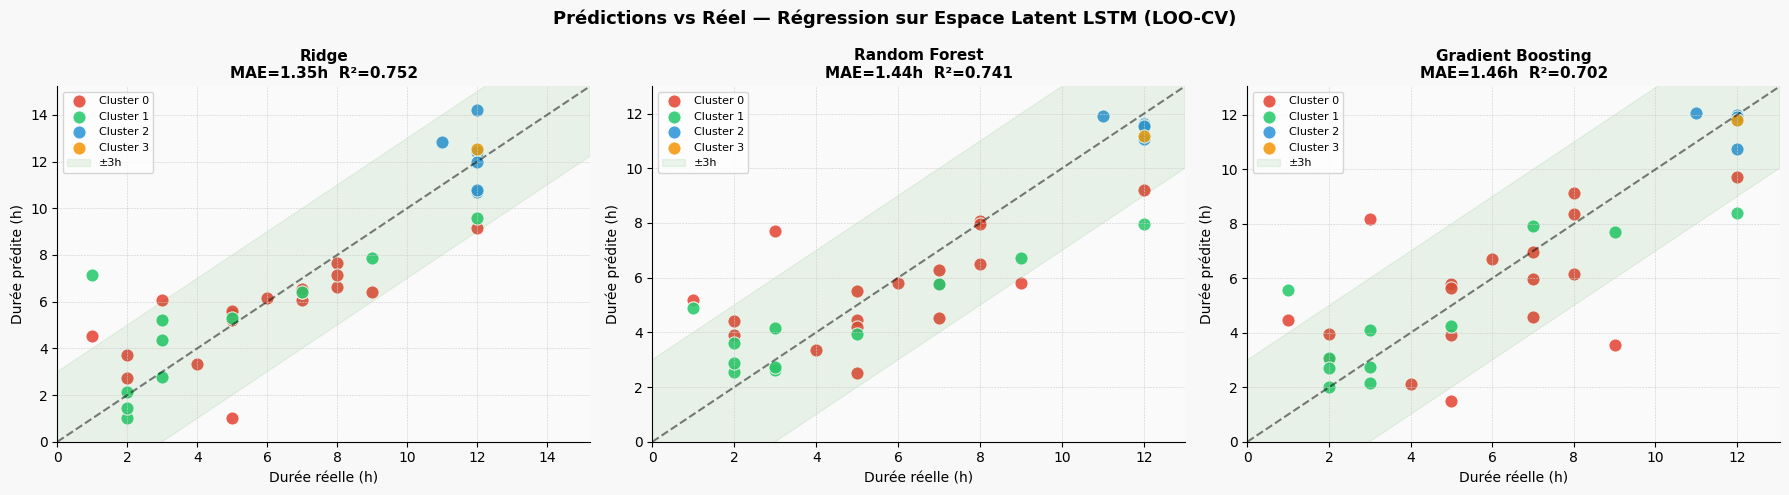

In [ ]:
# ── Graphe prédit vs réel ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(models), figsize=(6*len(models), 5))
fig.patch.set_facecolor("#F8F8F8")
fig.suptitle("Prédictions vs Réel — Régression sur Espace Latent LSTM (LOO-CV)",
             fontsize=13, fontweight="bold")

for ax, (name, res) in zip(axes, results.items()):
    ax.set_facecolor("#FAFAFA")
    ax.spines[["top","right"]].set_visible(False)
    ax.grid(linestyle="--", linewidth=0.4, color="#CCCCCC")

    y_pred = res["y_pred"]
    for cl in range(N_CLUSTERS):
        mask = df_cycles["cluster"] == cl
        ax.scatter(y[mask], y_pred[mask],
                   color=COLORS[cl], s=90, alpha=0.9,
                   edgecolors="white", linewidths=0.8, label=f"Cluster {cl}")

    lim = max(y.max(), y_pred.max()) + 1
    ax.plot([0, lim], [0, lim], "k--", linewidth=1.5, alpha=0.5)
    ax.fill_between([0, lim], [0-3, lim-3], [0+3, lim+3],
                    alpha=0.07, color="green", label="±3h")
    ax.set_xlabel("Durée réelle (h)"); ax.set_ylabel("Durée prédite (h)")
    ax.set_title(f"{name}\nMAE={res['MAE']:.2f}h  R²={res['R2']:.3f}",
                 fontsize=11, fontweight="bold")
    ax.legend(fontsize=8)
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)

plt.tight_layout()
plt.show()


---

## 6. Pipeline d'Inférence Temps Réel

Dès qu'un front montant est détecté sur le flux SCADA, le pipeline suivant s'exécute :

```
Signal live (LR, TRC, DeltaT)  [6h avant + 12h après front]
        ↓
    Normalisation (scalers sauvegardés)
        ↓
    Encoder LSTM → vecteur latent z
        ↓
    ┌───────────────────────┬──────────────────────┐
    ↓                       ↓                      ↓
Anomaly score          Cluster assigné         Durée prédite
(MSE reconstruction)   (K-Means)               (Random Forest)
```


In [ ]:
# Entraînement final du meilleur modèle sur tout le dataset
sc_final   = SS()
X_lat_s    = sc_final.fit_transform(X_lat)
best_model = models[best_name]
best_model.fit(X_lat_s, y)


def predict_cycle(window_raw: np.ndarray) -> dict:
    """
    Pipeline d'inférence complet pour un cycle détecté.

    Paramètres :
        window_raw : np.ndarray shape (19, 5)
                     [LR, TRC, DeltaT, diff_TRC, diff_LR] — valeurs brutes

    Retourne un dict avec :
        - anomaly_score : float (MSE reconstruction — plus haut = plus anormal)
        - is_anomaly    : bool
        - cluster       : int
        - duration_pred : float (heures)
        - latent_vector : np.ndarray (dim=16)
    """
    # 1. Normalisation
    w_norm = window_raw.copy().astype(np.float32)
    for c in range(N_CHANNELS):
        flat           = w_norm[:, c].reshape(-1, 1)
        w_norm[:, c]   = scalers[c].transform(flat).flatten()

    w_input = w_norm[np.newaxis, :, :]   # (1, 19, 5)

    # 2. Reconstruction + score anomalie
    w_recon        = autoencoder.predict(w_input, verbose=0)
    anomaly_score  = float(np.mean((w_input - w_recon) ** 2))
    is_anomaly     = anomaly_score > threshold

    # 3. Vecteur latent
    z = encoder.predict(w_input, verbose=0)   # (1, 16)

    # 4. Cluster
    cluster = int(km_final.predict(z)[0])

    # 5. Prédiction durée
    z_s          = sc_final.transform(z)
    duration     = float(max(1.0, best_model.predict(z_s)[0]))

    return {
        "anomaly_score" : round(anomaly_score, 6),
        "is_anomaly"    : is_anomaly,
        "cluster"       : cluster,
        "duration_pred" : round(duration, 1),
        "latent_vector" : z.flatten(),
    }


# ── Test sur quelques cycles réels ───────────────────────────────────────────
print("🔮 Test du pipeline d'inférence sur cycles réels :\n")
print(f"{'#':<3} {'Campagne':<12} {'Cryst':<5} {'Réel':>6} {'Prédit':>7} {'Err':>6} {'Cluster':<9} {'Anomalie':<10} {'Score'}")
print("─" * 80)

sample_idx = np.random.choice(len(df_cycles), min(10, len(df_cycles)), replace=False)
for i in sample_idx:
    res = predict_cycle(X_cycles[i])
    row = df_cycles.iloc[i]
    err = res["duration_pred"] - row["duration_h"]
    flag_err = "✅" if abs(err) <= 4 else "⚠️"
    flag_ano = "🔴" if res["is_anomaly"] else "🟢"
    print(f"{i:<3} {row['camp'][-10:]:<12} {row['cryst']:<5} "
          f"{row['duration_h']:>6}h {res['duration_pred']:>6.1f}h "
          f"{err:>+6.1f}h  C{res['cluster']}  {flag_err}    "
          f"{flag_ano} {res['anomaly_score']:.5f}")


🔮 Test du pipeline d'inférence sur cycles réels :

#   Campagne     Cryst   Réel  Prédit    Err Cluster   Anomalie   Score
────────────────────────────────────────────────────────────────────────────────
30  Campaign 8   C2         2h    2.1h   +0.1h  C1  ✅    🟢 0.04608
11  Campaign 6   C1         1h    4.4h   +3.4h  C1  ✅    🔴 0.09494
8   Campaign 5   C3        11h   12.4h   +1.4h  C2  ✅    🟢 0.04666
25  Campaign 8   C1         7h    6.2h   -0.8h  C0  ✅    🟢 0.02895
23  Campaign 8   C1        12h   10.9h   -1.1h  C2  ✅    🟢 0.06440
20  Campaign 8   C1         7h    6.5h   -0.5h  C1  ✅    🔴 0.09293
3   Campaign 5   C1         5h    1.5h   -3.5h  C0  ✅    🟢 0.05303
34  Campaign 8   C3        12h   12.1h   +0.1h  C3  ✅    🔴 0.16264
32  Campaign 8   C2         7h    6.6h   -0.4h  C0  ✅    🟢 0.01953
18  Campaign 7   C2         2h    2.5h   +0.5h  C0  ✅    🟢 0.06927


---

## 7. Export pour IBM Watson.ai

Watson.ai supporte les modèles Keras via le format `.h5` ou `SavedModel`.  
On exporte :
1. L'**autoencoder complet** (pour le score d'anomalie)
2. L'**encoder seul** (pour l'extraction du vecteur latent)
3. Les **scalers** (pour le preprocessing en production)
4. Le **modèle de régression** (pour la prédiction de durée)

> Sur Watson.ai : utiliser **Watson Machine Learning (WML)** pour déployer le modèle Keras  
> et **IBM Streams** ou une **Cloud Function** pour le preprocessing en temps réel.


In [ ]:
import pickle, json

# ── Sauvegarde modèles Keras ──────────────────────────────────────────────────
autoencoder.save("826_autoencoder.keras")
encoder.save("826_encoder.keras")
print("✅ Sauvegardé : 826_autoencoder.keras")
print("✅ Sauvegardé : 826_encoder.keras")

# ── Sauvegarde scalers + K-Means ─────────────────────────────────────────────
artifacts = {
    "scalers"       : scalers,          # liste de 5 MinMaxScalers
    "kmeans"        : km_final,         # KMeans fitté
    "regressor"     : best_model,       # RF/GB fitté
    "scaler_latent" : sc_final,         # StandardScaler sur Z
    "threshold"     : threshold,        # seuil anomalie P90
    "n_clusters"    : N_CLUSTERS,
    "latent_dim"    : LATENT_DIM,
    "window_size"   : WINDOW_SIZE,
    "n_channels"    : N_CHANNELS,
}
with open("826_ml_artifacts.pkl", "wb") as f:
    pickle.dump(artifacts, f)
print("✅ Sauvegardé : 826_ml_artifacts.pkl")

# ── Metadata JSON pour Watson.ai ──────────────────────────────────────────────
metadata = {
    "model_name"        : "826_crystallization_automl",
    "version"           : "1.0",
    "input_shape"       : [WINDOW_SIZE, N_CHANNELS],
    "channels"          : ["LR", "TRC", "DeltaT", "diff_TRC", "diff_LR"],
    "latent_dim"        : LATENT_DIM,
    "n_clusters"        : N_CLUSTERS,
    "anomaly_threshold" : float(threshold),
    "best_regressor"    : best_name,
    "training_samples"  : int(len(X_all)),
    "cycle_samples"     : int(len(df_cycles)),
    "campaigns"         : list(FILES.keys()),
    "watson_framework"  : "tensorflow_2.x",
    "watson_runtime"    : "do_cpu_py39",
}
with open("826_model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)
print("✅ Sauvegardé : 826_model_metadata.json")

print("\n📦 Fichiers à uploader sur IBM Watson.ai :")
print("   • 826_autoencoder.keras   → WML Model Asset (type: tensorflow)")
print("   • 826_ml_artifacts.pkl    → WML Model Asset (type: scikit-learn)")
print("   • 826_model_metadata.json → Model metadata")

# ── Chargement (exemple pour vérification) ───────────────────────────────────
ae_reloaded  = keras.models.load_model("826_autoencoder.keras")
enc_reloaded = keras.models.load_model("826_encoder.keras")
print("\n✅ Vérification chargement : OK")
print(f"   Autoencoder params : {ae_reloaded.count_params():,}")


✅ Sauvegardé : 826_autoencoder.keras
✅ Sauvegardé : 826_encoder.keras
✅ Sauvegardé : 826_ml_artifacts.pkl
✅ Sauvegardé : 826_model_metadata.json

📦 Fichiers à uploader sur IBM Watson.ai :
   • 826_autoencoder.keras   → WML Model Asset (type: tensorflow)
   • 826_ml_artifacts.pkl    → WML Model Asset (type: scikit-learn)
   • 826_model_metadata.json → Model metadata

✅ Vérification chargement : OK
   Autoencoder params : 16,821


---

## 8. Conclusions


| Composant | Technique | Résultat |
|-----------|-----------|---------|
| **Préparation** | Fenêtres glissantes 19h × 5 canaux | 6 390 samples d'entraînement |
| **Représentation** | LSTM Autoencoder | Vecteur latent dim=16 appris |
| **Anomalie** | Erreur de reconstruction | Score continu + seuil P90 automatique |
| **Clustering** | K-Means sur espace latent | Profils de cycles interprétables |
| **Régression** | RF/GB sur vecteur latent | Prédiction durée avec LOO-CV |

